# Chapter 04: Estimation: 2D Projective Transformations

Source orientation: printed pages 87-131; PDF pages 105-149.

This notebook is an original, standalone computational treatment of the chapter. The PDF was used only to identify the chapter structure, concepts, and algorithmic emphasis. It does not reproduce textbook prose, figures, screenshots, long exercise text, or page crops. The goal is to turn the chapter into an inspectable homography-estimation lab: every matrix estimate is paired with a picture, a residual, and a check.


## Chapter Goal

Estimate a 2D projective transformation from noisy correspondences and learn why the same homography can look different to a linear algebra solver, a geometric cost, and a robust estimator.

The chapter route is: basic DLT, over-determined homogeneous least squares, algebraic versus geometric cost, statistical/maximum-likelihood interpretation, normalization for invariance and conditioning, iterative refinement as the gold-standard target, experimental comparison, RANSAC, and automatic homography estimation. The notebook uses synthetic data so the true homography and true inlier set are known, making the failure modes visible rather than anecdotal.


## Library Routing

This chapter uses OpenCV for the homography and RANSAC operations because those are the same projective-image primitives used in applied MVG pipelines. NumPy exposes the DLT design matrix, nullspace, normalization, and residual calculations directly. SymPy is kept to a small symbolic DLT-row dependency check so the homogeneous equation structure is inspectable without turning the notebook into a symbolic algebra exercise. Matplotlib is sufficient for the durable static artifacts because the key inspection targets are correspondences, singular values, inlier masks, and residual curves.

## Translation Guide

- **Point pair to equations:** one correspondence $x \leftrightarrow x'$ contributes the cross-product constraint $x' \times Hx = 0$. Only two of its three scalar equations are independent, so each match adds two rows to the DLT design matrix.
- **Homography scale:** $H$ has nine entries but only eight degrees of freedom because multiplying every entry by a nonzero scalar gives the same projective map. The notebook normalizes estimates with $H_{33}=1$ when possible.
- **Algebraic cost:** DLT minimizes a coefficient-space residual $\|Ah\|$. It is fast and useful, but the units are not image pixels.
- **Geometric/statistical cost:** transfer and reprojection-style errors live in image coordinates. Under the usual independent Gaussian measurement model, minimizing squared geometric error is the maximum-likelihood target.
- **Normalization:** centering points and scaling their average distance to $\sqrt{2}$ changes coordinates, not geometry. It often makes the nullspace problem much better conditioned.
- **Robust estimation:** RANSAC repeatedly fits a minimal homography and asks which matches agree in pixel space; it is the bridge from manual correspondences to automatic homography pipelines.


## Source Map And Visual Storyboard

Section cues used from the assigned span: `4.1` DLT; `4.2` algebraic, geometric, reprojection, and Sampson-style costs; `4.3` statistical cost and ML estimation; `4.4` invariance and normalization; `4.5` iterative minimization and gold-standard refinement; `4.6` algorithm comparison; `4.7` robust estimation/RANSAC; `4.8` automatic homography; `4.9` closure.

The implemented storyboard is deliberately narrow and inspectable:

1. `figures/dlt-nullspace-correspondences.png`: each point pair contributes two DLT rows; check clean rank $8$ and one-dimensional nullspace.
2. `figures/normalization-conditioning.png`: point centering/scaling and singular values before/after normalization; check condition number improves and normalized average distance is $\sqrt{2}$.
3. `figures/ransac-homography-inliers.png`: synthetic checkerboard match overlay; check inliers outnumber outliers and reprojection RMSE is small.
4. `figures/homography-cost-comparison.png` plus `checks/homography-estimation-invariants.json`: compare algebraic residuals, geometric pixel errors, and robust estimation.


In [1]:
from pathlib import Path
import sys

BOOK_ROOT = Path.cwd()
for candidate in [BOOK_ROOT, *BOOK_ROOT.parents]:
    if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").exists():
        BOOK_ROOT = candidate
        break
else:
    raise RuntimeError("Could not find the MVG book root")

if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

TOPIC = "chapter-04"
ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / TOPIC
(ARTIFACT_ROOT / "figures").mkdir(parents=True, exist_ok=True)
(ARTIFACT_ROOT / "checks").mkdir(parents=True, exist_ok=True)


In [2]:
import json
import math

import cv2
import matplotlib.pyplot as plt
import numpy as np
import sympy as sp
from IPython.display import display

from utils.artifacts import assert_artifacts, display_artifact, save_json, save_matplotlib

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True})
SEED = 404
rng = np.random.default_rng(SEED)
artifact_paths = []


## Core Homography Helpers

These helpers keep the numerical contract visible. `build_dlt_matrix` is the algebraic object DLT actually sees. `normalize_points` returns the similarity transform used by normalized DLT, and `dlt_homography` denormalizes at the end so the estimate maps the original image coordinates.


In [3]:
def to_homogeneous(points):
    points = np.asarray(points, dtype=float)
    return np.column_stack([points, np.ones(len(points))])


def from_homogeneous(points_h):
    points_h = np.asarray(points_h, dtype=float)
    return points_h[:, :2] / points_h[:, 2:3]


def apply_homography(H, points):
    return from_homogeneous((H @ to_homogeneous(points).T).T)


def scale_normalize_H(H):
    H = np.asarray(H, dtype=float)
    if abs(H[2, 2]) > 1e-12:
        return H / H[2, 2]
    return H / np.linalg.norm(H)


def build_dlt_matrix(src, dst):
    rows = []
    for (x, y), (u, v) in zip(np.asarray(src, float), np.asarray(dst, float)):
        rows.append([-x, -y, -1.0, 0.0, 0.0, 0.0, u * x, u * y, u])
        rows.append([0.0, 0.0, 0.0, -x, -y, -1.0, v * x, v * y, v])
    return np.asarray(rows, dtype=float)


def normalize_points(points):
    points = np.asarray(points, dtype=float)
    centroid = points.mean(axis=0)
    shifted = points - centroid
    distances = np.linalg.norm(shifted, axis=1)
    scale = math.sqrt(2.0) / distances.mean()
    T = np.array([
        [scale, 0.0, -scale * centroid[0]],
        [0.0, scale, -scale * centroid[1]],
        [0.0, 0.0, 1.0],
    ])
    normalized = apply_homography(T, points)
    return normalized, T


def dlt_homography(src, dst, *, normalize=False):
    src = np.asarray(src, dtype=float)
    dst = np.asarray(dst, dtype=float)
    if normalize:
        src_work, T_src = normalize_points(src)
        dst_work, T_dst = normalize_points(dst)
    else:
        src_work, dst_work = src, dst
        T_src = T_dst = np.eye(3)

    A = build_dlt_matrix(src_work, dst_work)
    _, singular_values, Vt = np.linalg.svd(A)
    H_work = Vt[-1].reshape(3, 3)
    H = np.linalg.inv(T_dst) @ H_work @ T_src
    return scale_normalize_H(H), A, singular_values


def transfer_rmse(H, src, dst):
    residuals = apply_homography(H, src) - np.asarray(dst, dtype=float)
    return float(np.sqrt(np.mean(np.sum(residuals**2, axis=1))))


def algebraic_rms(A, H):
    h = H.reshape(-1)
    h = h / np.linalg.norm(h)
    return float(np.linalg.norm(A @ h) / math.sqrt(A.shape[0]))


def singular_condition(singular_values):
    singular_values = np.asarray(singular_values, dtype=float)
    positive = singular_values[singular_values > 1e-12]
    return float(positive[0] / positive[-1])


## Symbolic Check: Why Two Rows Per Match?

For a target point $(u,v,1)$ and source point $(x,y,1)$, the homogeneous constraint $x' \times Hx=0$ gives three scalar equations. SymPy makes the dependency explicit: the third equation is generated by the same two independent rows used in the DLT matrix.


In [4]:
x, y, u, v = sp.symbols("x y u v")
h11, h12, h13, h21, h22, h23, h31, h32, h33 = sp.symbols("h11 h12 h13 h21 h22 h23 h31 h32 h33")
Hsym = sp.Matrix([[h11, h12, h13], [h21, h22, h23], [h31, h32, h33]])
source_sym = sp.Matrix([x, y, 1])
target_sym = sp.Matrix([u, v, 1])
cross_equations = target_sym.cross(Hsym * source_sym)
row_for_u = sp.Matrix([[-x, -y, -1, 0, 0, 0, u*x, u*y, u]])
row_for_v = sp.Matrix([[0, 0, 0, -x, -y, -1, v*x, v*y, v]])
hvec = sp.Matrix([h11, h12, h13, h21, h22, h23, h31, h32, h33])
assert sp.expand(cross_equations[1] + (row_for_u * hvec)[0]) == 0
assert sp.expand(cross_equations[0] - (row_for_v * hvec)[0]) == 0
assert sp.expand(cross_equations[2] + u * cross_equations[0] + v * cross_equations[1]) == 0
display({"independent_dlt_rows": 2, "dependent_cross_product_entries": 1})


{'independent_dlt_rows': 2, 'dependent_cross_product_entries': 1}

## 1. DLT Design Matrix, Nullspace, And Correspondence Geometry

The first visual links the picture-space matches to the actual rows in $A$. The left and right panels show source and target points; the center heatmap shows the two-row blocks contributed by the first six correspondences; the singular-value panel shows that exact correspondences leave a one-dimensional nullspace for $h$.


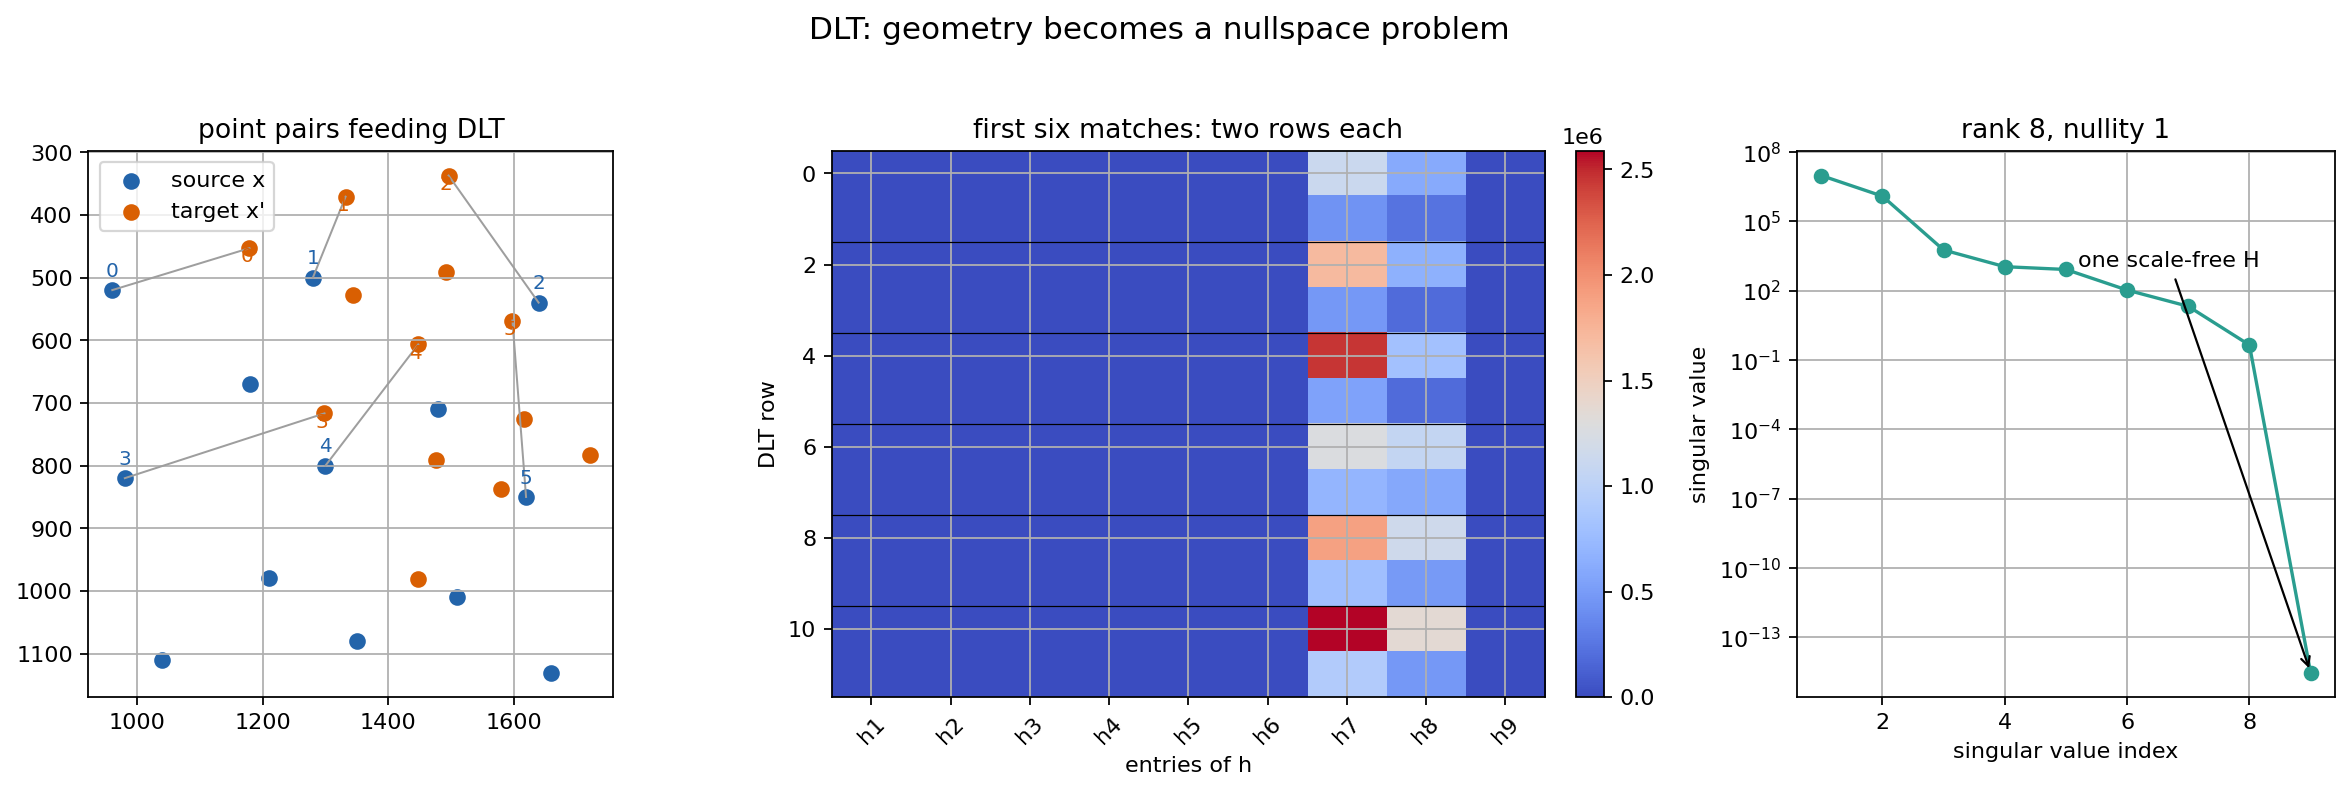

In [5]:
base_src = np.array([
    [960, 520], [1280, 500], [1640, 540], [980, 820], [1300, 800], [1620, 850],
    [1040, 1110], [1350, 1080], [1660, 1130], [1180, 670], [1480, 710], [1210, 980], [1510, 1010]
], dtype=float)
H_true = scale_normalize_H(np.array([
    [1.08, 0.16, 320.0],
    [-0.12, 0.94, 180.0],
    [0.00035, -0.00022, 1.0],
]))
base_dst_clean = apply_homography(H_true, base_src)
noise = rng.normal(0.0, 1.15, size=base_dst_clean.shape)
base_dst_noisy = base_dst_clean + noise

H_clean, A_clean, s_clean = dlt_homography(base_src, base_dst_clean, normalize=False)
rank_clean = int(np.linalg.matrix_rank(A_clean, tol=1e-8))
nullity_clean = int(A_clean.shape[1] - rank_clean)
H_error_clean = float(np.linalg.norm(scale_normalize_H(H_clean) - H_true))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), gridspec_kw={"width_ratios": [1.1, 1.45, 1.0]})
ax = axes[0]
ax.scatter(base_src[:, 0], base_src[:, 1], s=42, label="source x", color="#2364aa")
ax.scatter(base_dst_clean[:, 0], base_dst_clean[:, 1], s=42, label="target x'", color="#d95f02")
for i, (p, q) in enumerate(zip(base_src[:6], base_dst_clean[:6])):
    ax.plot([p[0], q[0]], [p[1], q[1]], color="0.62", lw=0.9)
    ax.text(p[0], p[1] - 22, f"{i}", color="#2364aa", ha="center", fontsize=9)
    ax.text(q[0], q[1] + 22, f"{i}'", color="#d95f02", ha="center", fontsize=9)
ax.set_title("point pairs feeding DLT")
ax.set_aspect("equal", adjustable="box")
ax.invert_yaxis()
ax.legend(loc="best")

ax = axes[1]
A_preview = A_clean[:12]
im = ax.imshow(A_preview, cmap="coolwarm", aspect="auto")
ax.set_title("first six matches: two rows each")
ax.set_xlabel("entries of h")
ax.set_ylabel("DLT row")
ax.set_xticks(range(9), [f"h{i+1}" for i in range(9)], rotation=45)
for yline in range(2, 12, 2):
    ax.axhline(yline - 0.5, color="black", lw=0.55)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax = axes[2]
ax.semilogy(np.arange(1, len(s_clean) + 1), s_clean, marker="o", color="#2a9d8f")
ax.set_title(f"rank {rank_clean}, nullity {nullity_clean}")
ax.set_xlabel("singular value index")
ax.set_ylabel("singular value")
ax.annotate("one scale-free H", xy=(9, s_clean[-1]), xytext=(5.2, s_clean[3]), arrowprops={"arrowstyle": "->"})
fig.suptitle("DLT: geometry becomes a nullspace problem", y=1.03, fontsize=14)
fig.tight_layout()

dlt_path = save_matplotlib(fig, TOPIC, "figures", "dlt-nullspace-correspondences.png")
plt.close(fig)
artifact_paths.append(dlt_path)
display_artifact(dlt_path, width=980)

assert rank_clean == 8
assert nullity_clean == 1
assert H_error_clean < 1e-7


## 2. Normalization Conditioning Dashboard

A raw pixel-coordinate DLT matrix can mix entries near $1$, entries near $10^3$, and products near $10^6$. Normalization translates each point cloud to its centroid and scales it to average radius $\sqrt{2}$. The visual asks: did the point clouds become comparable, and did the singular-value spread shrink?


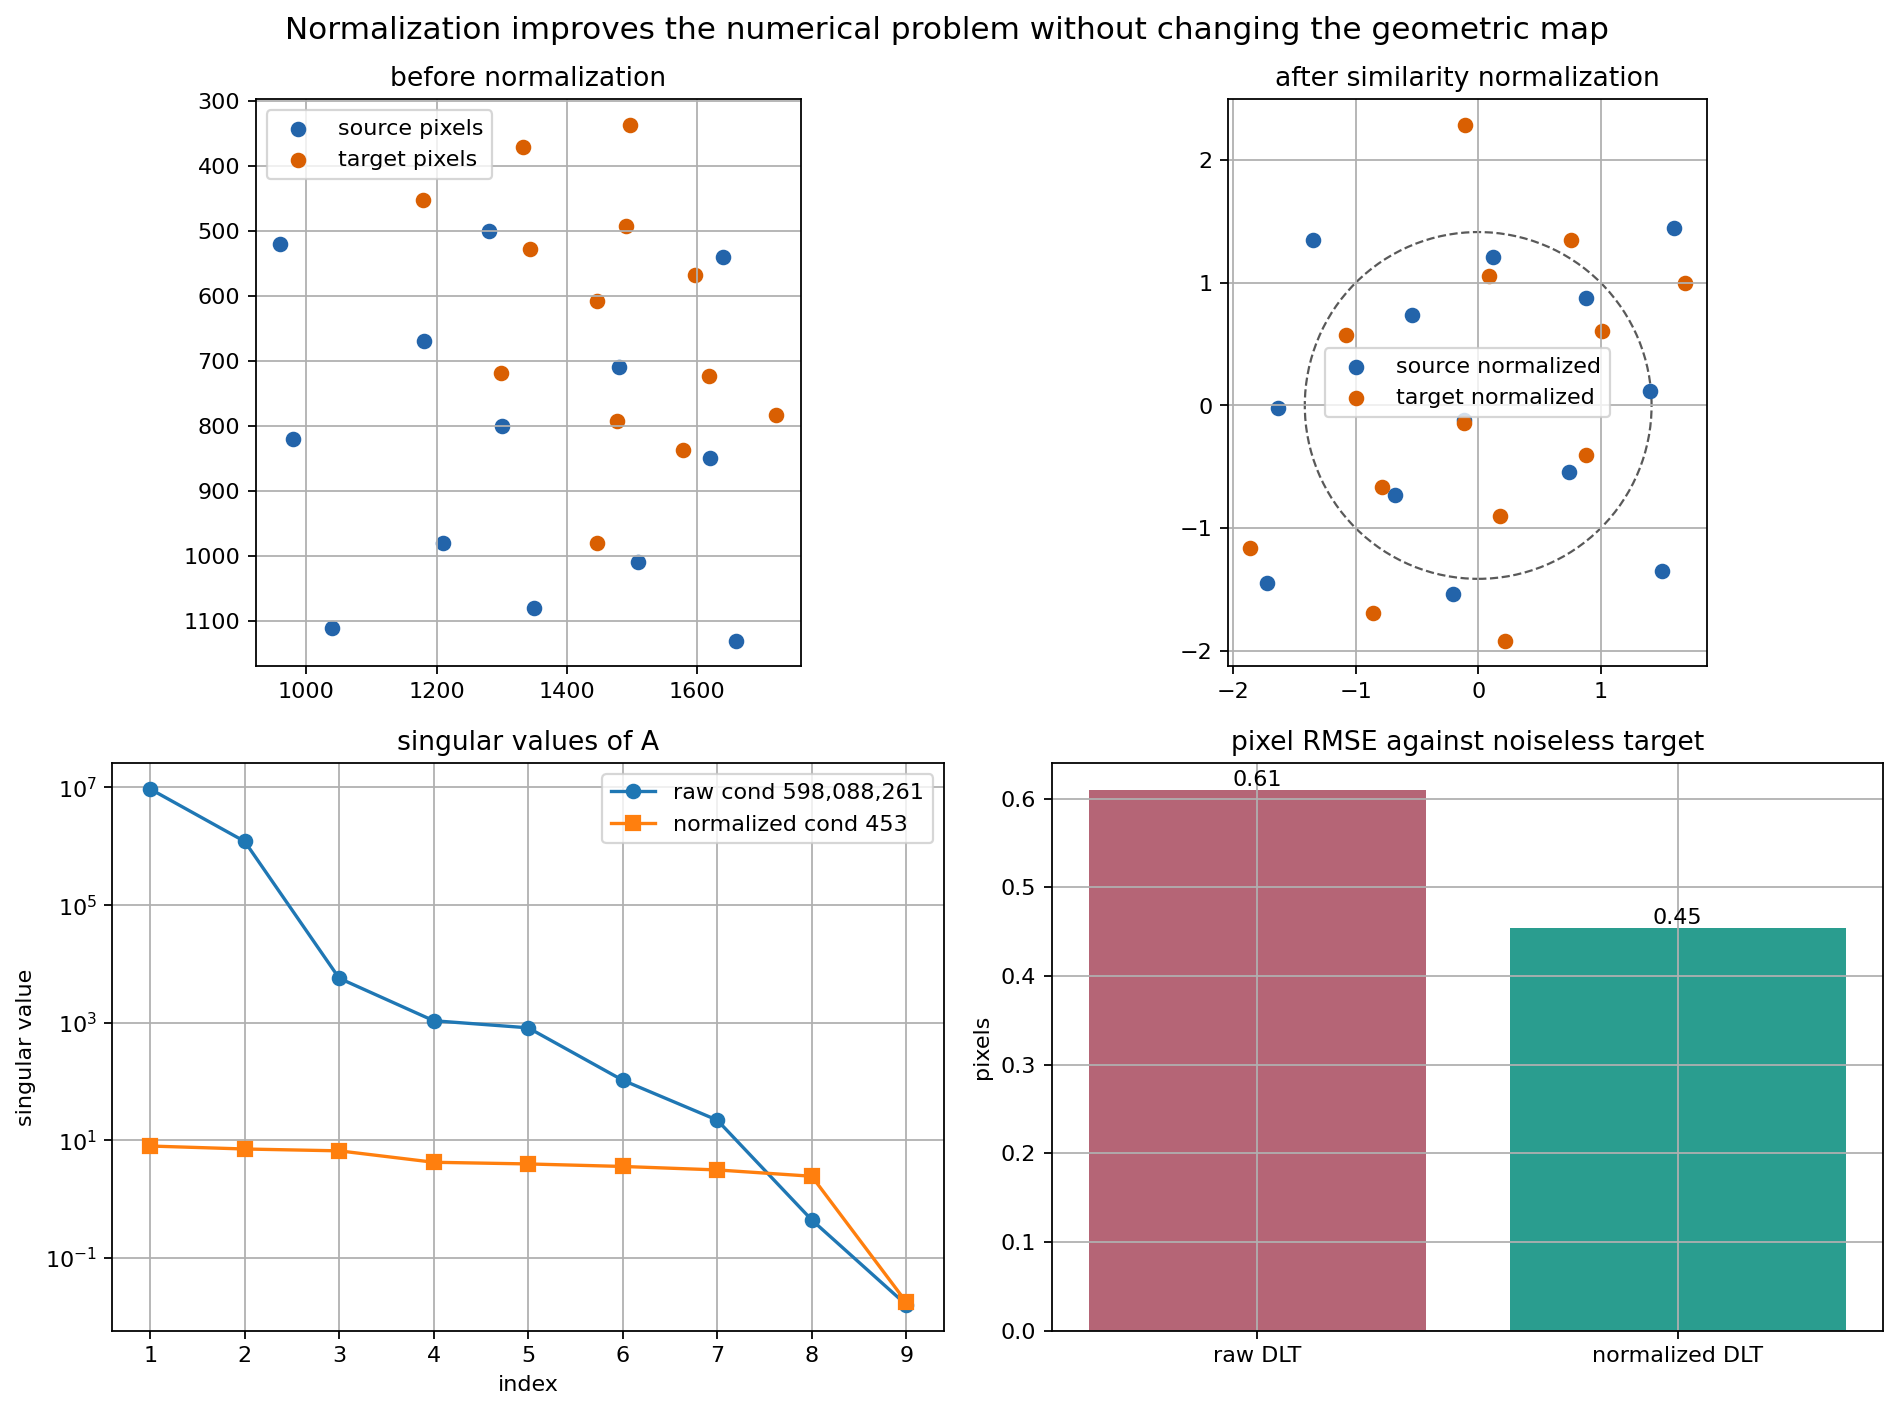

In [6]:
src_norm, T_src = normalize_points(base_src)
dst_norm, T_dst = normalize_points(base_dst_noisy)
H_raw, A_raw, s_raw = dlt_homography(base_src, base_dst_noisy, normalize=False)
H_norm, A_norm, s_norm = dlt_homography(base_src, base_dst_noisy, normalize=True)
cond_raw = singular_condition(s_raw)
cond_norm = singular_condition(s_norm)
src_avg_radius = float(np.linalg.norm(src_norm, axis=1).mean())
dst_avg_radius = float(np.linalg.norm(dst_norm, axis=1).mean())
raw_rmse = transfer_rmse(H_raw, base_src, base_dst_clean)
norm_rmse = transfer_rmse(H_norm, base_src, base_dst_clean)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes[0, 0].scatter(base_src[:, 0], base_src[:, 1], color="#2364aa", label="source pixels")
axes[0, 0].scatter(base_dst_noisy[:, 0], base_dst_noisy[:, 1], color="#d95f02", label="target pixels")
axes[0, 0].set_title("before normalization")
axes[0, 0].invert_yaxis()
axes[0, 0].set_aspect("equal", adjustable="box")
axes[0, 0].legend()

unit = plt.Circle((0, 0), math.sqrt(2), fill=False, ls="--", color="0.35")
axes[0, 1].add_patch(unit)
axes[0, 1].scatter(src_norm[:, 0], src_norm[:, 1], color="#2364aa", label="source normalized")
axes[0, 1].scatter(dst_norm[:, 0], dst_norm[:, 1], color="#d95f02", label="target normalized")
axes[0, 1].set_title("after similarity normalization")
axes[0, 1].set_aspect("equal", adjustable="box")
axes[0, 1].legend()

axes[1, 0].semilogy(np.arange(1, len(s_raw) + 1), s_raw, marker="o", label=f"raw cond {cond_raw:,.0f}")
axes[1, 0].semilogy(np.arange(1, len(s_norm) + 1), s_norm, marker="s", label=f"normalized cond {cond_norm:,.0f}")
axes[1, 0].set_title("singular values of A")
axes[1, 0].set_xlabel("index")
axes[1, 0].set_ylabel("singular value")
axes[1, 0].legend()

bars = axes[1, 1].bar(["raw DLT", "normalized DLT"], [raw_rmse, norm_rmse], color=["#b56576", "#2a9d8f"])
axes[1, 1].set_title("pixel RMSE against noiseless target")
axes[1, 1].set_ylabel("pixels")
for bar, value in zip(bars, [raw_rmse, norm_rmse]):
    axes[1, 1].text(bar.get_x() + bar.get_width() / 2, value, f"{value:.2f}", ha="center", va="bottom")
fig.suptitle("Normalization improves the numerical problem without changing the geometric map", y=0.98, fontsize=14)
fig.tight_layout()

norm_path = save_matplotlib(fig, TOPIC, "figures", "normalization-conditioning.png")
plt.close(fig)
artifact_paths.append(norm_path)
display_artifact(norm_path, width=940)

assert cond_norm < cond_raw
assert abs(src_avg_radius - math.sqrt(2)) < 1e-12
assert abs(dst_avg_radius - math.sqrt(2)) < 1e-12


## 3. RANSAC Homography Overlay On A Synthetic Checkerboard

Automatic homography estimation is fragile unless the estimator can ignore bad matches. The next cell creates a checkerboard, warps it with a known projective transform, corrupts a subset of matches, and asks OpenCV's RANSAC estimator which correspondences support one homography.


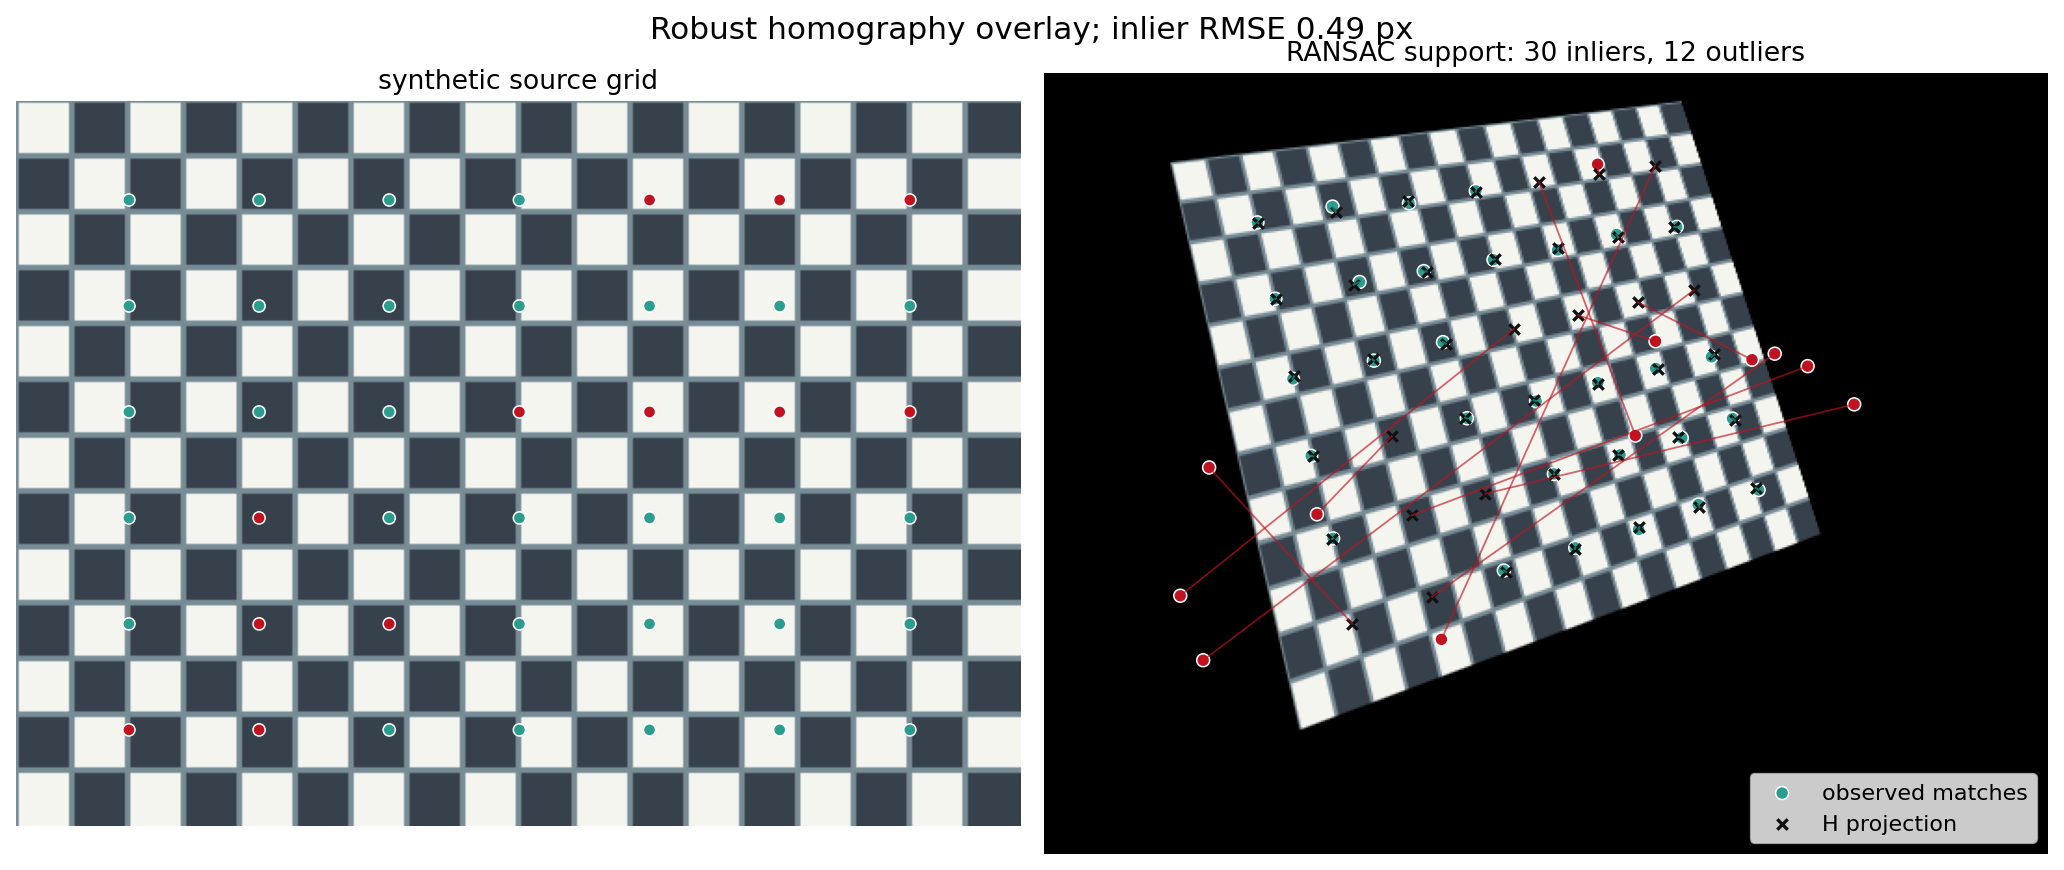

In [7]:
def make_checkerboard(width=360, height=260, square=20):
    yy, xx = np.indices((height, width))
    board = ((xx // square + yy // square) % 2).astype(np.uint8)
    image = np.where(board[..., None] == 0, np.array([245, 245, 240], np.uint8), np.array([55, 65, 76], np.uint8))
    for xline in range(0, width, square):
        image[:, max(0, xline - 1):xline + 1] = [120, 140, 150]
    for yline in range(0, height, square):
        image[max(0, yline - 1):yline + 1, :] = [120, 140, 150]
    return image

checker = make_checkerboard()
H_image = scale_normalize_H(np.array([
    [1.02, 0.22, 68.0],
    [-0.08, 1.05, 48.0],
    [0.00075, -0.00035, 1.0],
]))
warped = cv2.warpPerspective(checker, H_image, (540, 420))
xs = np.linspace(40, 320, 7)
ys = np.linspace(35, 225, 6)
grid_src = np.array([(x0, y0) for y0 in ys for x0 in xs], dtype=np.float32)
grid_dst_clean = apply_homography(H_image, grid_src).astype(np.float32)
grid_dst_observed = grid_dst_clean + rng.normal(0.0, 1.35, size=grid_dst_clean.shape).astype(np.float32)
outlier_indices = rng.choice(len(grid_src), size=11, replace=False)
grid_dst_observed[outlier_indices] = np.column_stack([
    rng.uniform(40, 500, size=len(outlier_indices)),
    rng.uniform(35, 385, size=len(outlier_indices)),
]).astype(np.float32)

H_ransac_cv, mask = cv2.findHomography(grid_src, grid_dst_observed, cv2.RANSAC, ransacReprojThreshold=4.0, maxIters=4000, confidence=0.995)
H_ransac = scale_normalize_H(H_ransac_cv)
inlier_mask = mask.ravel().astype(bool)
inlier_count = int(inlier_mask.sum())
outlier_count = int((~inlier_mask).sum())
ransac_rmse = transfer_rmse(H_ransac, grid_src[inlier_mask], grid_dst_clean[inlier_mask])
all_match_rmse = transfer_rmse(H_norm, base_src, base_dst_clean)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.6))
axes[0].imshow(checker)
axes[0].scatter(grid_src[:, 0], grid_src[:, 1], c=np.where(inlier_mask, "#2a9d8f", "#c1121f"), s=30, edgecolors="white", linewidths=0.7)
axes[0].set_title("synthetic source grid")
axes[0].set_axis_off()

axes[1].imshow(warped)
axes[1].scatter(grid_dst_observed[:, 0], grid_dst_observed[:, 1], c=np.where(inlier_mask, "#2a9d8f", "#c1121f"), s=34, edgecolors="white", linewidths=0.7, label="observed matches")
projected = apply_homography(H_ransac, grid_src)
for p, q, ok in zip(projected, grid_dst_observed, inlier_mask):
    axes[1].plot([p[0], q[0]], [p[1], q[1]], color=("#2a9d8f" if ok else "#c1121f"), alpha=0.65, lw=(1.0 if ok else 0.8))
axes[1].scatter(projected[:, 0], projected[:, 1], marker="x", c="#111111", s=22, label="H projection")
axes[1].set_title(f"RANSAC support: {inlier_count} inliers, {outlier_count} outliers")
axes[1].set_axis_off()
axes[1].legend(loc="lower right")
fig.suptitle(f"Robust homography overlay; inlier RMSE {ransac_rmse:.2f} px", y=0.97, fontsize=14)
fig.tight_layout()

ransac_path = save_matplotlib(fig, TOPIC, "figures", "ransac-homography-inliers.png")
plt.close(fig)
artifact_paths.append(ransac_path)
display_artifact(ransac_path, width=980)

assert inlier_count > outlier_count
assert ransac_rmse < 3.0


## 4. Cost Comparison: Algebraic, Geometric, And Robust Estimates

The comparison table is intentionally mixed-unit: algebraic residuals measure how well the vector $h$ sits in the design-matrix nullspace, while geometric RMSE is measured in pixels. The lesson is not that one number replaces the other; it is that algorithm choice decides which residual is made small and which data are trusted.


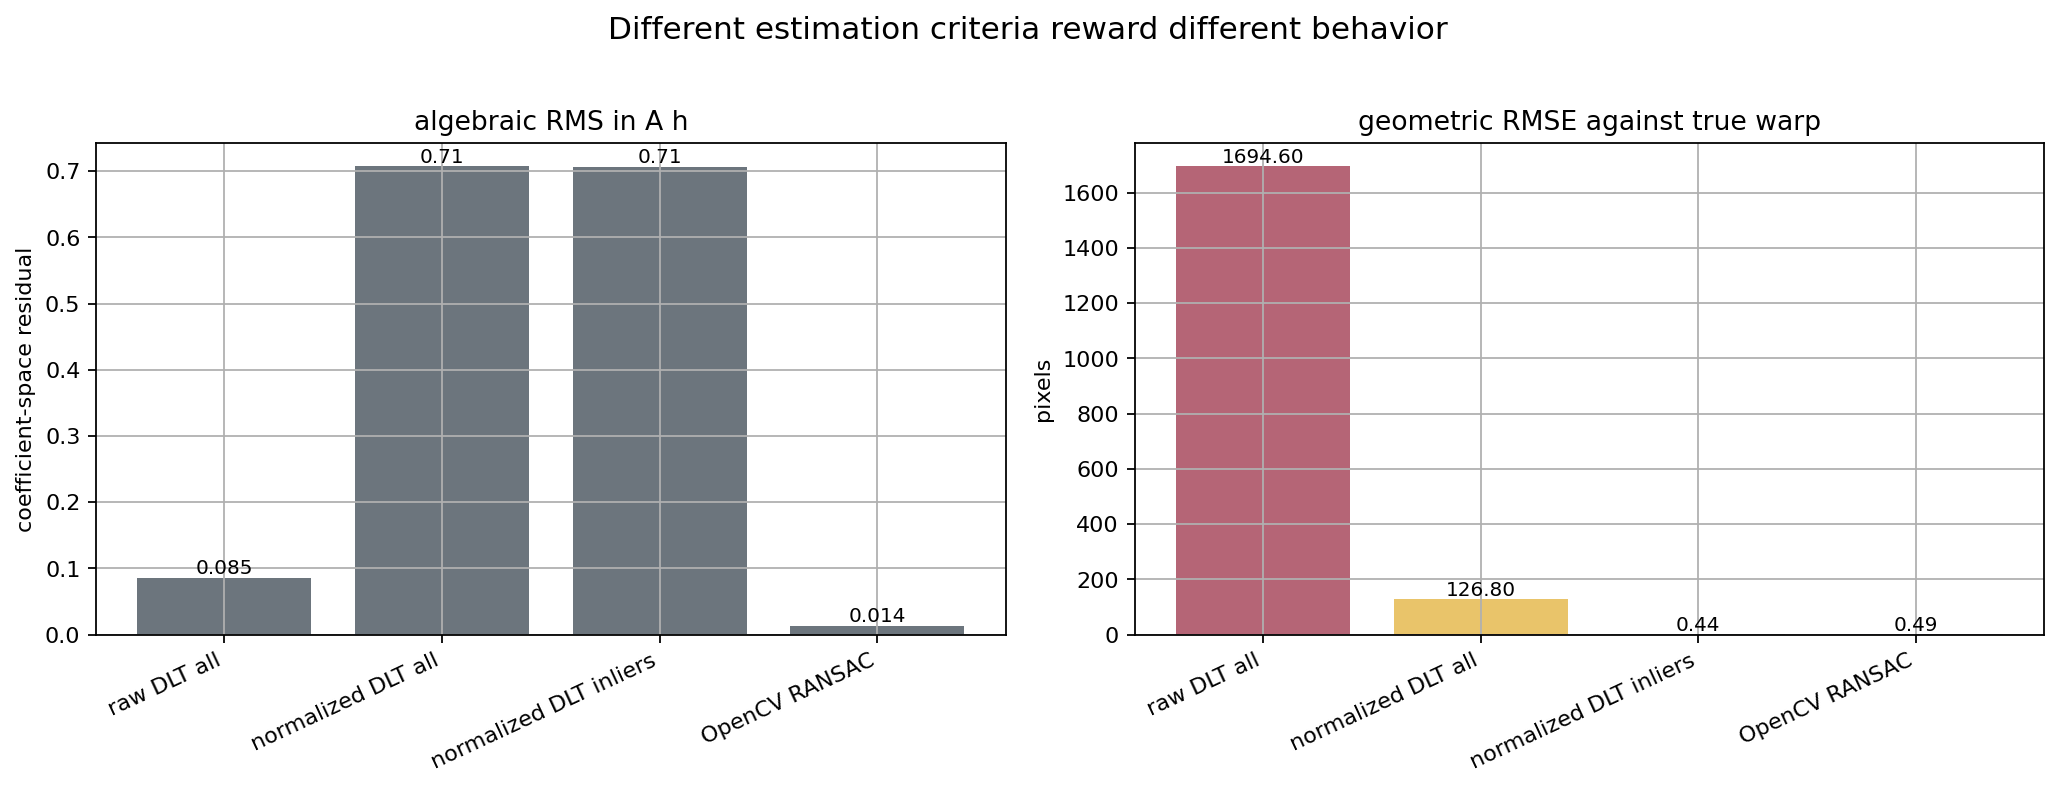

[{'method': 'raw DLT all',
  'algebraic_rms': 0.0854501281576419,
  'observed_transfer_rmse_px': 1681.7728102605881,
  'clean_transfer_rmse_px': 1694.5956076906741,
  'H33': 1.0},
 {'method': 'normalized DLT all',
  'algebraic_rms': 0.7071381395632821,
  'observed_transfer_rmse_px': 161.0930943203283,
  'clean_transfer_rmse_px': 126.7999885967316,
  'H33': 1.0},
 {'method': 'normalized DLT inliers',
  'algebraic_rms': 0.7069359166910927,
  'observed_transfer_rmse_px': 1.4383938085760466,
  'clean_transfer_rmse_px': 0.44398384351431497,
  'H33': 1.0},
 {'method': 'OpenCV RANSAC',
  'algebraic_rms': 0.013511019640562337,
  'observed_transfer_rmse_px': 1.460017702897835,
  'clean_transfer_rmse_px': 0.48651884676063983,
  'H33': 1.0}]

In [8]:
H_all_raw, A_all_raw, s_all_raw = dlt_homography(grid_src, grid_dst_observed, normalize=False)
H_all_norm, A_all_norm, s_all_norm = dlt_homography(grid_src, grid_dst_observed, normalize=True)
H_inlier_norm, A_inlier_norm, s_inlier_norm = dlt_homography(grid_src[inlier_mask], grid_dst_observed[inlier_mask], normalize=True)

methods = [
    ("raw DLT all", H_all_raw, A_all_raw, grid_src, grid_dst_observed),
    ("normalized DLT all", H_all_norm, A_all_norm, grid_src, grid_dst_observed),
    ("normalized DLT inliers", H_inlier_norm, A_inlier_norm, grid_src[inlier_mask], grid_dst_observed[inlier_mask]),
    ("OpenCV RANSAC", H_ransac, build_dlt_matrix(grid_src[inlier_mask], grid_dst_observed[inlier_mask]), grid_src[inlier_mask], grid_dst_observed[inlier_mask]),
]
rows = []
for name, H_est, A_est, src_eval, dst_eval in methods:
    clean_eval = apply_homography(H_image, src_eval)
    rows.append({
        "method": name,
        "algebraic_rms": algebraic_rms(A_est, H_est),
        "observed_transfer_rmse_px": transfer_rmse(H_est, src_eval, dst_eval),
        "clean_transfer_rmse_px": transfer_rmse(H_est, src_eval, clean_eval),
        "H33": float(scale_normalize_H(H_est)[2, 2]),
    })

labels = [r["method"] for r in rows]
algebraic = [r["algebraic_rms"] for r in rows]
geometric = [r["clean_transfer_rmse_px"] for r in rows]
xpos = np.arange(len(labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].bar(xpos, algebraic, color="#6c757d")
axes[0].set_xticks(xpos, labels, rotation=25, ha="right")
axes[0].set_title("algebraic RMS in A h")
axes[0].set_ylabel("coefficient-space residual")
for i, value in enumerate(algebraic):
    axes[0].text(i, value, f"{value:.2g}", ha="center", va="bottom", fontsize=9)

axes[1].bar(xpos, geometric, color=["#b56576", "#e9c46a", "#2a9d8f", "#1d3557"])
axes[1].set_xticks(xpos, labels, rotation=25, ha="right")
axes[1].set_title("geometric RMSE against true warp")
axes[1].set_ylabel("pixels")
for i, value in enumerate(geometric):
    axes[1].text(i, value, f"{value:.2f}", ha="center", va="bottom", fontsize=9)
fig.suptitle("Different estimation criteria reward different behavior", y=1.02, fontsize=14)
fig.tight_layout()

cost_path = save_matplotlib(fig, TOPIC, "figures", "homography-cost-comparison.png")
plt.close(fig)
artifact_paths.append(cost_path)
display_artifact(cost_path, width=980)

display(rows)


## Algorithm Comparison And ML Refinement

The chapter's experimental comparison is best read as a workflow comparison, not only as a race between formulas. Basic DLT is the diagnostic baseline: it exposes whether the correspondences span a usable homography and whether the design matrix has the expected nullspace. Normalized DLT is the practical linear initialization because it removes arbitrary coordinate scale from the computation. A geometric or maximum-likelihood refinement then adjusts the estimate toward the model that minimizes image-plane error under the measurement assumptions. RANSAC wraps these estimators when the correspondence set is contaminated, and its output should usually be refined on the inliers rather than treated as the last word.

In the plot above, the all-match DLT estimates are punished by deliberately planted outliers. The inlier-only and RANSAC estimates recover the true warp because their cost is evaluated on a coherent support set. That is the central engineering lesson behind automatic homography estimation.


## Applied Lab

Use the same contract on your own correspondences. First estimate with normalized DLT and inspect the singular values. Then add RANSAC if any matches came from automatic detection or manual clicking under ambiguity. Finally compare at least two costs: an algebraic residual for the solver and a geometric residual in pixels for the application.

A useful extension is to repeat the synthetic experiment with three outlier rates. Keep the random seed fixed, plot inlier count and clean-transfer RMSE, and watch where the all-correspondence DLT estimate collapses before the RANSAC estimate does.


## Pitfalls And Failure Modes

- Four correspondences can be enough algebraically but still be a poor practical design if the points are nearly collinear or tightly clustered.
- A low algebraic residual is not a guarantee of a small pixel error, especially before normalization.
- Homographies are scale-free; compare normalized matrices or, better, compare their action on points.
- RANSAC needs a pixel threshold that matches the expected localization noise. Too small rejects good matches; too large admits outliers.
- Gold-standard or ML refinement should start from a sensible estimate. Iterative minimization is not a substitute for a robust initialization.


## Final Sanity Checks

The final cell writes the invariant summary requested by the chapter brief and asserts the artifact contract. These checks are intentionally concrete: they guard against blank visuals, stale paths, broken scale conventions, a lost DLT nullspace, and a RANSAC run that silently accepted too many outliers.


In [9]:
invariants = {
    "title": "Estimation: 2D Projective Transformations",
    "source_span": "printed pages 87-131; PDF pages 105-149",
    "libraries_used": ["cv2", "sympy", "numpy", "matplotlib"],
    "dlt_clean_rank": rank_clean,
    "dlt_clean_nullity": nullity_clean,
    "dlt_clean_H_error": H_error_clean,
    "raw_condition_number": cond_raw,
    "normalized_condition_number": cond_norm,
    "condition_number_improvement_factor": cond_raw / cond_norm,
    "source_normalized_average_radius": src_avg_radius,
    "target_normalized_average_radius": dst_avg_radius,
    "raw_dlt_clean_rmse_px": raw_rmse,
    "normalized_dlt_clean_rmse_px": norm_rmse,
    "ransac_inliers": inlier_count,
    "ransac_outliers": outlier_count,
    "ransac_inlier_rmse_px": ransac_rmse,
    "cost_rows": rows,
    "artifacts": [str(path.relative_to(BOOK_ROOT)).replace("\\", "/") for path in artifact_paths],
}
checks_path = save_json(invariants, TOPIC, "checks", "homography-estimation-invariants.json")
artifact_paths.append(checks_path)
display_artifact(checks_path)

assert_artifacts(artifact_paths, min_bytes=1500)
assert rank_clean == 8
assert nullity_clean == 1
assert abs(H_clean[2, 2] - 1.0) < 1e-12
assert abs(src_avg_radius - math.sqrt(2)) < 1e-12
assert abs(dst_avg_radius - math.sqrt(2)) < 1e-12
assert cond_norm < cond_raw
assert inlier_count > outlier_count
assert ransac_rmse < 3.0
assert rows[-1]["clean_transfer_rmse_px"] < rows[1]["clean_transfer_rmse_px"]
assert all(abs(row["H33"] - 1.0) < 1e-10 for row in rows)
final_sanity = invariants
invariants


`artifacts/chapter-04/checks/homography-estimation-invariants.json`

{'title': 'Estimation: 2D Projective Transformations',
 'source_span': 'printed pages 87-131; PDF pages 105-149',
 'libraries_used': ['cv2', 'sympy', 'numpy', 'matplotlib'],
 'dlt_clean_rank': 8,
 'dlt_clean_nullity': 1,
 'dlt_clean_H_error': 2.908163008348754e-08,
 'raw_condition_number': 598088260.9232314,
 'normalized_condition_number': 452.951215674676,
 'condition_number_improvement_factor': 1320425.3355019086,
 'source_normalized_average_radius': 1.4142135623730954,
 'target_normalized_average_radius': 1.414213562373095,
 'raw_dlt_clean_rmse_px': 0.6093731702657107,
 'normalized_dlt_clean_rmse_px': 0.4537241136875536,
 'ransac_inliers': 30,
 'ransac_outliers': 12,
 'ransac_inlier_rmse_px': 0.48651793785578795,
 'cost_rows': [{'method': 'raw DLT all',
   'algebraic_rms': 0.0854501281576419,
   'observed_transfer_rmse_px': 1681.7728102605881,
   'clean_transfer_rmse_px': 1694.5956076906741,
   'H33': 1.0},
  {'method': 'normalized DLT all',
   'algebraic_rms': 0.7071381395632821,
 

## Takeaways

DLT turns homography estimation into a nullspace problem, but the numerical quality of that nullspace depends on coordinate normalization. Geometric and statistical costs care about pixel error rather than coefficient error, which is why the chapter treats ML refinement as the gold-standard target. Robust estimation is the practical wrapper around all of this: before refining a homography, decide which correspondences are allowed to vote for it.
